# Robustness Explanations -- Execution Time Analysis
This notebook provides a basic execution time analysis of robustness pockets, given synthetic QBAFs and their updates.

## Setup
First, we install QBAF-Py and matplotlib:

In [1]:
%%capture
!pip install git+https://github.com/TimKam/Quantitative-Bipolar-Argumentation.git@linear_expansion_pockets
!pip install matplotlib

Next, we print out CPU information (out-comment accordingly, depending on MAC or LINUX):

In [2]:
!cat /proc/cpuinfo

cat: /proc/cpuinfo: No such file or directory


In [3]:
!sysctl -a | grep machdep.cpu

machdep.cpu.cores_per_package: 10
machdep.cpu.core_count: 10
machdep.cpu.logical_per_package: 10
machdep.cpu.thread_count: 10
machdep.cpu.brand_string: Apple M4


We import a few dependencies:

In [4]:
import math, random, time

import matplotlib.pyplot as plt
from statistics import mean, median

from qbaf import QBAFramework, QBAFARelations
from qbaf_visualizer.Visualizer import *
from qbaf_robustness.consistency_checks import *
from qbaf_robustness.inconsistency_checks import *
from qbaf_robustness.explanations import *

## QBAF Generation

We generate *layered* QBAFs. Arguments in the bottom layer do not attack or support other arguments.
Arguments in the next layer only support or attack arguments in the bottom layer, and so forth.
Arguments in the final layer do not have any attackers or supporters.
An argument in a given layer has a $50\%$ chance to attack or support any argument in the next lower layer.
Attack versus support is again determined randomly, with a $50\%$ chance of each.
Each argument's strength is set randomly to a value in $[0, 1]$.

In [5]:
def generate_layered_qbaf(layers, connection_probability, semantics, min_strength=0, max_strength=1):
    args = []
    initial_strengths = []
    attacks = []
    supports = []
    args_by_layer = {}
    for index, layer in enumerate(layers):
        layer_args = []
        for i in range(0, layer):
            arg = f'a{index,i}'
            layer_args.append(arg)
            args.append(arg)
            initial_strengths.append(random.uniform(min_strength, max_strength))
            if not index == 0:
                for target_arg in args_by_layer[index-1]:
                    if random.random() < connection_probability:
                        if random.random() < 0.5:
                            attacks.append((arg, target_arg))
                        else:
                            supports.append((arg, target_arg))
        args_by_layer[index] = layer_args

    return QBAFramework(args, initial_strengths, attacks, supports, semantics=semantics)

Based on a layered QBAF, we construct a *QBAF chain*, i.e., a sequence of normal expansions, whose final element is the layered QBAF.
The chain has a fixed length, and expands the QBAF by an approximately equal number of arguments at each expansion step.

In [6]:
def generate_layered_qbaf_chain(length, topics, max_layers, connection_probability, semantics, min_strength=0, max_strength=1):
    max_qbaf = generate_layered_qbaf(max_layers, connection_probability, semantics, min_strength, max_strength)
    max_args = max_qbaf.arguments
    qbafs = []
    args = topics
    initial_strengths = [max_qbaf.initial_strength(topic) for topic in topics]
    attacks = []
    supports = []
    remaining_args = [arg for arg in max_args if not arg in topics]
    random.shuffle(remaining_args)
    chunks = [remaining_args[i::length] for i in range(length)]
    for chunk in chunks:
        for arg in chunk:
            args.append(arg)
            initial_strengths.append(max_qbaf.initial_strength(arg))
            attacks.extend([(arg, target) for target in max_qbaf.attackedBy(arg) if target in args])
            attacks.extend([(source, arg) for source in max_qbaf.attackersOf(arg) if source in args])
            supports.extend([(arg, target) for target in max_qbaf.supportedBy(arg) if target in args])
            supports.extend([(source, arg) for source in max_qbaf.supportersOf(arg) if source in args])
        qbaf = QBAFramework(args, initial_strengths, attacks, supports, semantics=semantics)
        qbafs.append(qbaf)
    return qbafs

## Maximal Pocket Computation
First, we empirically demonstrate that enumerating maximal pockets is challenging.
Based on a generated layered QBAF, we construct a sequence of normal expansions, whose final element is the layered QBAF.

### Bottom-Up Search
We then generate expansion chains as described above from layered QBAFs with between $9$ and $32$ arguments and up to $6$ layers.
The bottom layer contains only topic arguments. All following layers contain up to $6$ arguments, i.e., when the limit of $5$ arguments is reached for a given layer, a new layer is added.
For each layer configuration, we generate $5$ different QBAF chains to slightly stabilize the results.

In [7]:
layers = [2, 6]
for _ in range(2, 6):
    layers.append(0)
n_arguments_list = []
# DFQuAD
avg_pocket_times_dfquad = []
med_pocket_times_dfquad = []
max_pocket_times_dfquad = []
min_pocket_times_dfquad = []
# QE
avg_pocket_times_qe = []
med_pocket_times_qe = []
max_pocket_times_qe = []
min_pocket_times_qe = []

for i in range(2, 6):
    for j in range(1, 7):
        layers[i] = j
        n_arguments_list.append(sum(layers))
        pocket_times_dfquad = []
        pocket_times_qe = []
        for _ in range(0, 5):
            # DFQuAD
            qbafs = generate_layered_qbaf_chain(math.floor(sum(layers)/5), ['a(0, 0)', 'a(0, 1)'], layers, 0.5, "DFQuAD_model", min_strength=0.3, max_strength=0.7)
            start_time = time.time()
            pockets = determine_bottom_up_max_pockets(qbafs[0], qbafs, 'a(0, 0)', 'a(0, 1)')
            end_time = time.time()
            pocket_times_dfquad.append(end_time - start_time)
            print(f'DFQuAD, size {sum(layers)}, time {end_time - start_time}')
            # QE
            qbafs = generate_layered_qbaf_chain(math.floor(sum(layers)/5), ['a(0, 0)', 'a(0, 1)'], layers, 0.5, "QuadraticEnergy_model", min_strength=0.3, max_strength=0.7)
            start_time = time.time()
            pockets = determine_bottom_up_max_pockets(qbafs[0], qbafs, 'a(0, 0)', 'a(0, 1)')
            end_time = time.time()
            pocket_times_qe.append(end_time - start_time)
            print(f'QE, size {sum(layers)}, time {end_time - start_time}')
        avg_pocket_times_dfquad.append(mean(pocket_times_dfquad))
        avg_pocket_times_qe.append(mean(pocket_times_dfquad))
        med_pocket_times_dfquad.append(median(pocket_times_qe))
        med_pocket_times_qe.append(median(pocket_times_qe))
        max_pocket_times_dfquad.append(max(pocket_times_qe))
        max_pocket_times_qe.append(max(pocket_times_qe))
        min_pocket_times_dfquad.append(min(pocket_times_qe))
        min_pocket_times_qe.append(min(pocket_times_qe))
print(layers)

DFQuAD, size 9, time 5.9604644775390625e-06
QE, size 9, time 3.814697265625e-06
DFQuAD, size 9, time 2.86102294921875e-06
QE, size 9, time 9.5367431640625e-07
DFQuAD, size 9, time 1.9073486328125e-06
QE, size 9, time 9.5367431640625e-07
DFQuAD, size 9, time 9.5367431640625e-07
QE, size 9, time 1.1920928955078125e-06
DFQuAD, size 9, time 1.6689300537109375e-06
QE, size 9, time 1.9073486328125e-06
DFQuAD, size 10, time 6.103515625e-05
QE, size 10, time 3.0994415283203125e-05
DFQuAD, size 10, time 2.8848648071289062e-05
QE, size 10, time 2.8848648071289062e-05
DFQuAD, size 10, time 2.8848648071289062e-05
QE, size 10, time 2.9325485229492188e-05
DFQuAD, size 10, time 2.7894973754882812e-05
QE, size 10, time 2.9325485229492188e-05
DFQuAD, size 10, time 2.8133392333984375e-05
QE, size 10, time 2.8133392333984375e-05
DFQuAD, size 11, time 3.0994415283203125e-05
QE, size 11, time 2.9087066650390625e-05
DFQuAD, size 11, time 2.9325485229492188e-05
QE, size 11, time 2.9325485229492188e-05
DFQuAD

As we can see, computation time explodes with the exponential growth of the powerset (of potential pockets).

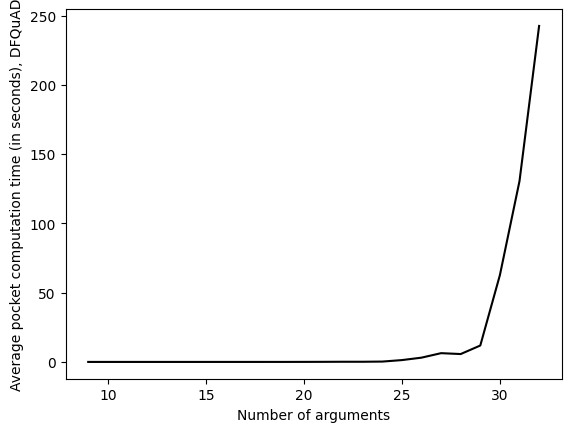

In [8]:
plot = plt.plot(n_arguments_list, avg_pocket_times_dfquad, color='black')
plt.ylabel('Average pocket computation time (in seconds), DFQuAD')
plt.xlabel('Number of arguments')
plt.savefig("avg_df_full.pdf", format="pdf")

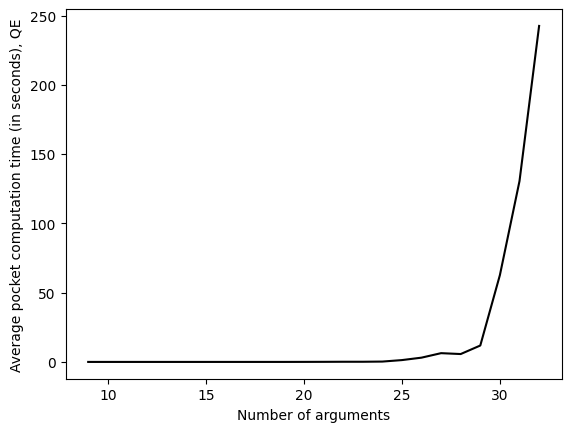

In [9]:
plot = plt.plot(n_arguments_list, avg_pocket_times_qe, color='black')
plt.ylabel('Average pocket computation time (in seconds), QE')
plt.xlabel('Number of arguments')
plt.savefig("avg_qe_full.pdf", format="pdf")

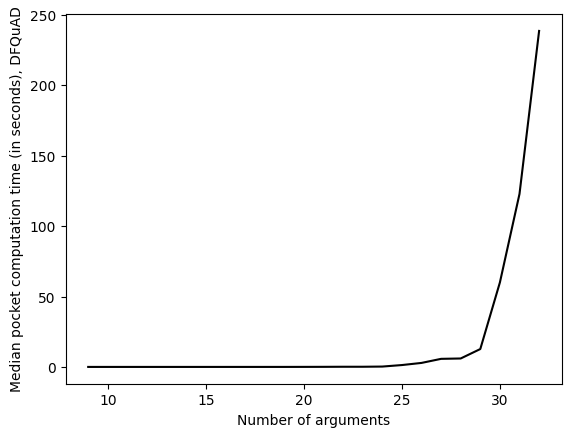

In [10]:
plot = plt.plot(n_arguments_list, med_pocket_times_dfquad, color='black')
plt.ylabel('Median pocket computation time (in seconds), DFQuAD')
plt.xlabel('Number of arguments')
plt.savefig("med_df_full.pdf", format="pdf")

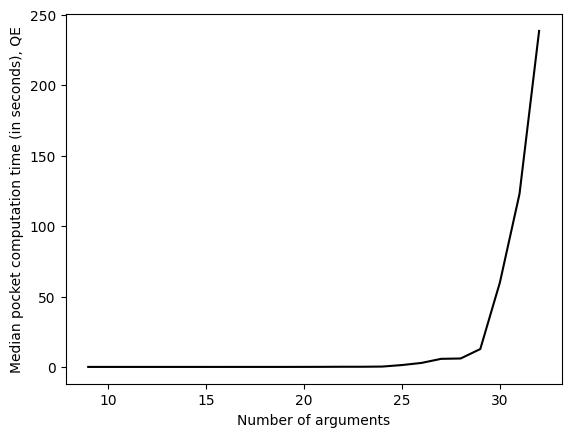

In [11]:
plot = plt.plot(n_arguments_list, med_pocket_times_qe, color='black')
plt.ylabel('Median pocket computation time (in seconds), QE')
plt.xlabel('Number of arguments')
plt.savefig("med_qe_full.pdf", format="pdf")

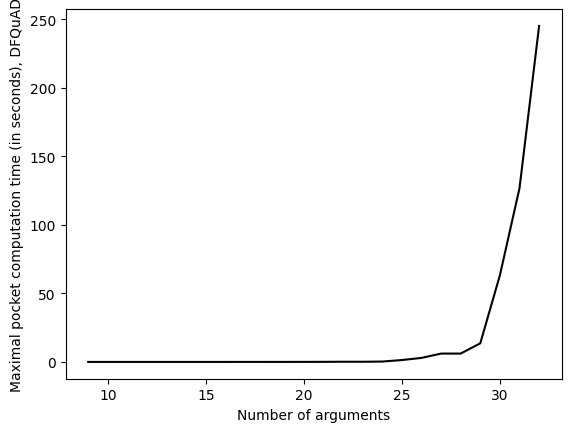

In [12]:
plot = plt.plot(n_arguments_list, max_pocket_times_dfquad, color='black')
plt.ylabel('Maximal pocket computation time (in seconds), DFQuAD')
plt.xlabel('Number of arguments')
plt.savefig("max_df_full.pdf", format="pdf")

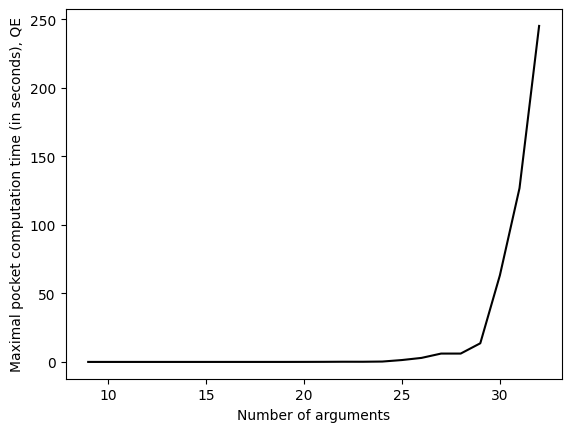

In [13]:
plot = plt.plot(n_arguments_list, max_pocket_times_qe, color='black')
plt.ylabel('Maximal pocket computation time (in seconds), QE')
plt.xlabel('Number of arguments')
plt.savefig("max_qe_full.pdf", format="pdf")

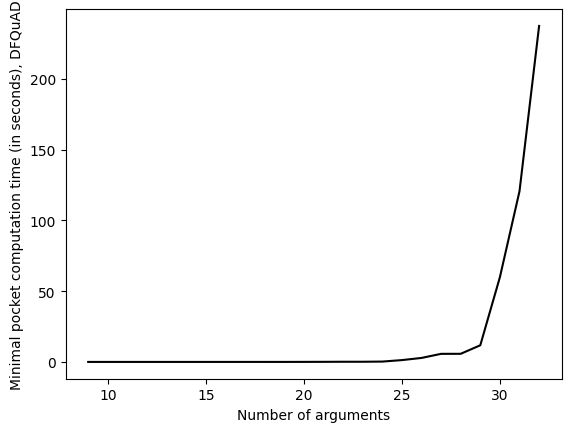

In [14]:
plot = plt.plot(n_arguments_list, min_pocket_times_dfquad, color='black')
plt.ylabel('Minimal pocket computation time (in seconds), DFQuAD')
plt.xlabel('Number of arguments')
plt.savefig("min_df_full.pdf", format="pdf")

/var/folders/02/jn8jztmn0t99803jw_s_j93m0000gn/T/ipykernel_47975/588572405.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


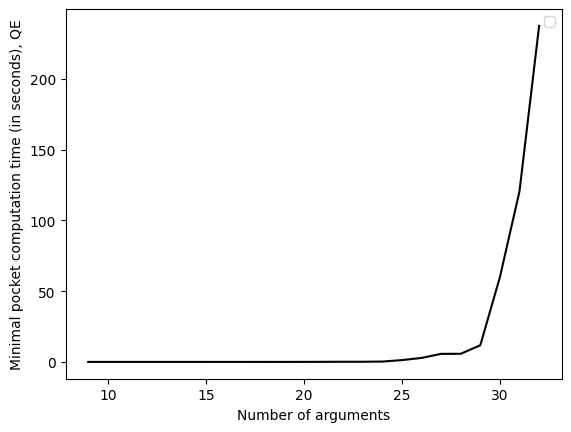

In [15]:
plot = plt.plot(n_arguments_list, min_pocket_times_qe, color='black')
plt.legend()
plt.ylabel('Minimal pocket computation time (in seconds), QE')
plt.xlabel('Number of arguments')
plt.savefig("min_qe_full.pdf", format="pdf")

### Top-Down Search
The top-down search that starts with the largest possible set and then gradually decreases set size is even slower in our scenario.
To evaluate it, we generate expansion chains as described above from layered QBAFs with between $7$ and $22$ arguments and up to $5$ layers.
The bottom layer contains only topic arguments. All following layers contain up to $5$ arguments, i.e., when the limit of $5$ arguments is reached for a given layer, a new layer is added.
For each layer configuration, we generate $5$ different QBAF chains to slightly stabilize the results.

In [16]:
layers = [2, 5]
for _ in range(2, 5):
    layers.append(0)
n_arguments_list = []
# DFQuAD
avg_pocket_times_dfquad = []
med_pocket_times_dfquad = []
max_pocket_times_dfquad = []
min_pocket_times_dfquad = []
# QE
avg_pocket_times_qe = []
med_pocket_times_qe = []
max_pocket_times_qe = []
min_pocket_times_qe = []

for i in range(2, 5):
    for j in range(1, 6):
        layers[i] = j
        n_arguments_list.append(sum(layers))
        pocket_times_dfquad = []
        pocket_times_qe = []
        for _ in range(0, 5):
            # DFQuAD
            qbafs = generate_layered_qbaf_chain(math.floor(sum(layers)/5), ['a(0, 0)', 'a(0, 1)'], layers, 0.5, "DFQuAD_model", min_strength=0.3, max_strength=0.7)
            start_time = time.time()
            pockets = determine_max_pockets(qbafs[0], qbafs, 'a(0, 0)', 'a(0, 1)')
            end_time = time.time()
            pocket_times_dfquad.append(end_time - start_time)
            print(f'DFQuAD, size {sum(layers)}, time {end_time - start_time}')
            # QE
            qbafs = generate_layered_qbaf_chain(math.floor(sum(layers)/5), ['a(0, 0)', 'a(0, 1)'], layers, 0.5, "QuadraticEnergy_model", min_strength=0.3, max_strength=0.7)
            start_time = time.time()
            pockets = determine_max_pockets(qbafs[0], qbafs, 'a(0, 0)', 'a(0, 1)')
            end_time = time.time()
            pocket_times_qe.append(end_time - start_time)
            print(f'QE, size {sum(layers)}, time {end_time - start_time}')
        avg_pocket_times_dfquad.append(mean(pocket_times_dfquad))
        avg_pocket_times_qe.append(mean(pocket_times_dfquad))
        med_pocket_times_dfquad.append(median(pocket_times_qe))
        med_pocket_times_qe.append(median(pocket_times_qe))
        max_pocket_times_dfquad.append(max(pocket_times_qe))
        max_pocket_times_qe.append(max(pocket_times_qe))
        min_pocket_times_dfquad.append(min(pocket_times_qe))
        min_pocket_times_qe.append(min(pocket_times_qe))
print(layers)

DFQuAD, size 8, time 1.3113021850585938e-05
QE, size 8, time 7.867813110351562e-06
DFQuAD, size 8, time 6.9141387939453125e-06
QE, size 8, time 6.198883056640625e-06
DFQuAD, size 8, time 5.9604644775390625e-06
QE, size 8, time 5.9604644775390625e-06
DFQuAD, size 8, time 5.0067901611328125e-06
QE, size 8, time 5.9604644775390625e-06
DFQuAD, size 8, time 5.245208740234375e-06
QE, size 8, time 6.198883056640625e-06
DFQuAD, size 9, time 6.9141387939453125e-06
QE, size 9, time 8.106231689453125e-06
DFQuAD, size 9, time 6.9141387939453125e-06
QE, size 9, time 6.9141387939453125e-06
DFQuAD, size 9, time 6.9141387939453125e-06
QE, size 9, time 6.9141387939453125e-06
DFQuAD, size 9, time 6.198883056640625e-06
QE, size 9, time 5.7220458984375e-06
DFQuAD, size 9, time 8.344650268554688e-06
QE, size 9, time 6.9141387939453125e-06
DFQuAD, size 10, time 1.5020370483398438e-05
QE, size 10, time 2.1696090698242188e-05
DFQuAD, size 10, time 1.4066696166992188e-05
QE, size 10, time 1.3113021850585938e-0

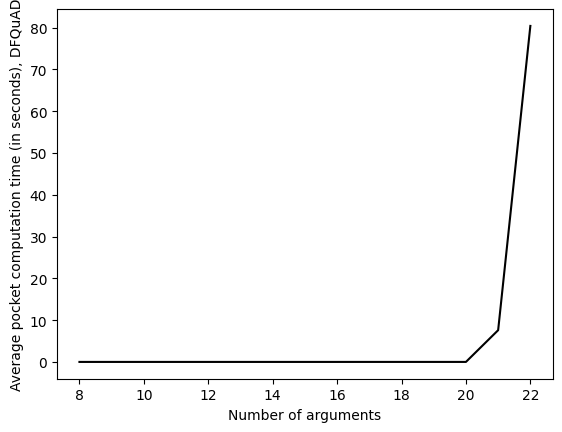

In [17]:
plot = plt.plot(n_arguments_list, avg_pocket_times_dfquad, color='black')
plt.ylabel('Average pocket computation time (in seconds), DFQuAD')
plt.xlabel('Number of arguments')
plt.savefig("td_avg_df_full.pdf", format="pdf")

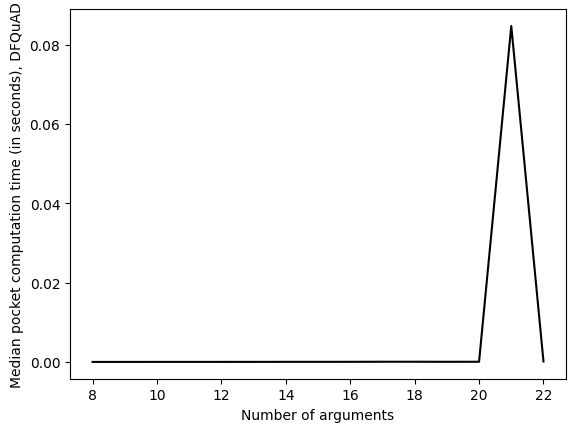

In [18]:
plot = plt.plot(n_arguments_list, med_pocket_times_dfquad, color='black')
plt.ylabel('Median pocket computation time (in seconds), DFQuAD')
plt.xlabel('Number of arguments')
plt.savefig("td_med_df_full.pdf", format="pdf")

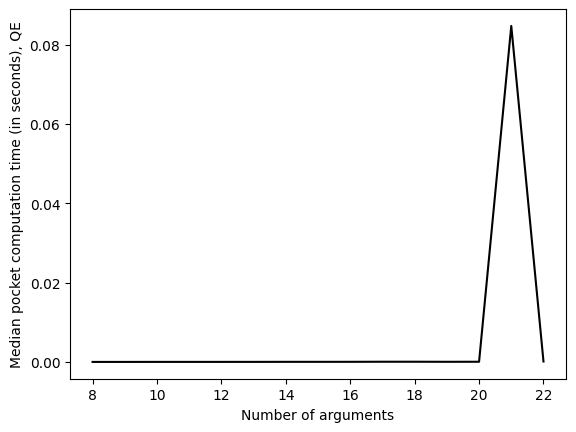

In [19]:
plot = plt.plot(n_arguments_list, med_pocket_times_qe, color='black')
plt.ylabel('Median pocket computation time (in seconds), QE')
plt.xlabel('Number of arguments')
plt.savefig("td_med_qe_full.pdf", format="pdf")

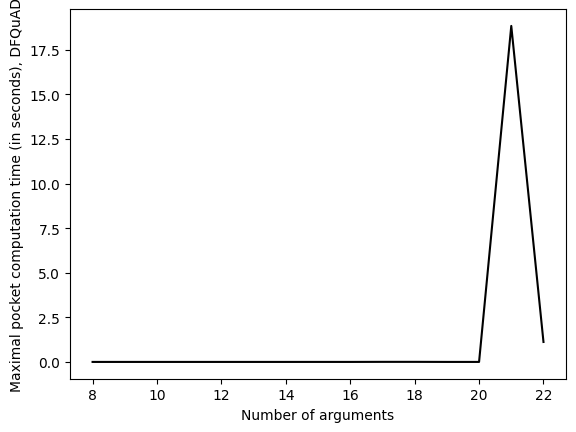

In [20]:
plot = plt.plot(n_arguments_list, max_pocket_times_dfquad, color='black')
plt.ylabel('Maximal pocket computation time (in seconds), DFQuAD')
plt.xlabel('Number of arguments')
plt.savefig("td_max_df_full.pdf", format="pdf")

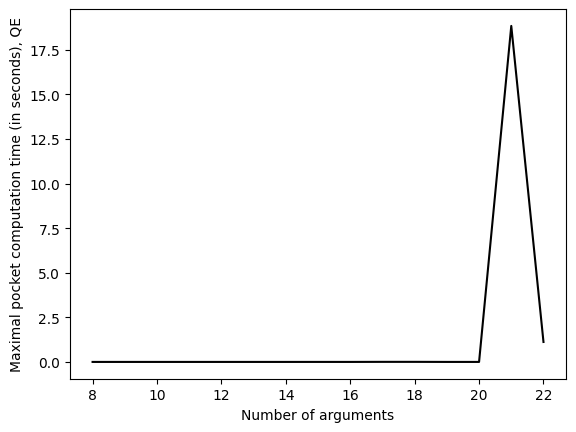

In [21]:
plot = plt.plot(n_arguments_list, max_pocket_times_qe, color='black')
plt.ylabel('Maximal pocket computation time (in seconds), QE')
plt.xlabel('Number of arguments')
plt.savefig("td_max_qe_full.pdf", format="pdf")

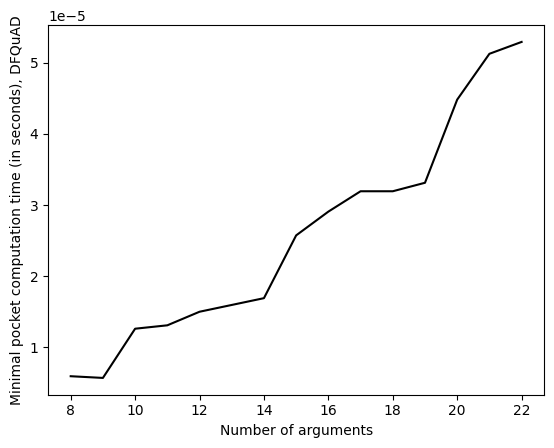

In [22]:
plot = plt.plot(n_arguments_list, min_pocket_times_dfquad, color='black')
plt.ylabel('Minimal pocket computation time (in seconds), DFQuAD')
plt.xlabel('Number of arguments')
plt.savefig("td_min_df_full.pdf", format="pdf")

/var/folders/02/jn8jztmn0t99803jw_s_j93m0000gn/T/ipykernel_47975/3063752244.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


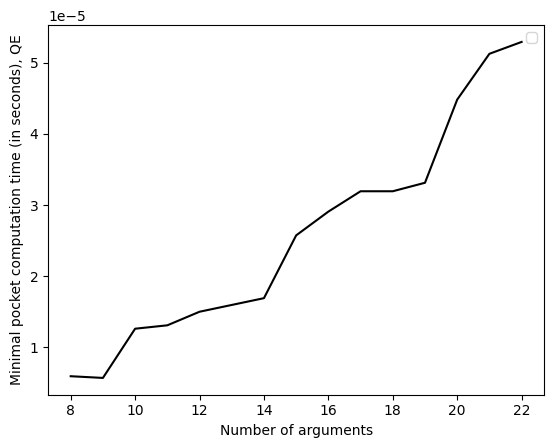

In [23]:
plot = plt.plot(n_arguments_list, min_pocket_times_qe, color='black')
plt.legend()
plt.ylabel('Minimal pocket computation time (in seconds), QE')
plt.xlabel('Number of arguments')
plt.savefig("td_min_qe_full.pdf", format="pdf")

## Pragmatic Pocket Computation for Expansion Chains
However, we can pragmatically compute *large* pockets that help us assess the robustness of expansion chains.
In many use cases, we may be interested in assessing where robustness fails in a normal expansion chain that, e.g., models an argumentation dialogue.
Then, we can first narrow down the robustness failure to two QBAFs in the chain, i.e., the first QBAF for which the inference is not robust and its predecessor.
Given these two QBAFs, we can then compute maximal pockets.
These pockets may not be maximal for the entire chain of QBAFs: intuitively, arguments that are entirely irrelevant to our inference may be added later on, for example, thus not affecting robustness of inference.
Still, the pockets, alongside any argument that has been added when expanding from the predecessor, help explain failure of robustness.
Importantly, these pockets may often be computed quickly, as the search space is reduced to the powerset of arguments that have been added with one specific expansion; however, the problem is still intractable in the worst case. As computation is faster than in the previous experimental setup we repeat pocket computation (and QBAF generation) for a given graph/chain size $20$ times.

In [24]:
layers = [2, 10]
for _ in range(0, 20):
    layers.append(0)
n_arguments_list = []
# DFQuAD
avg_pocket_times_dfquad = []
med_pocket_times_dfquad = []
max_pocket_times_dfquad = []
min_pocket_times_dfquad = []
# QE
avg_pocket_times_qe = []
med_pocket_times_qe = []
max_pocket_times_qe = []
min_pocket_times_qe = []

for i in range(2, 20):
    for j in range(1, 21):
        layers[i] = j
        n_arguments_list.append(sum(layers))
        pocket_times_dfquad = []
        pocket_times_qe = []
        for _ in range(0, 20):
            # DFQuAD
            qbafs = generate_layered_qbaf_chain(math.floor(sum(layers)/5), ['a(0, 0)', 'a(0, 1)'], layers, 0.5, "DFQuAD_model", min_strength=0.3, max_strength=0.7)
            start_time = time.time()
            pockets = determine_linear_pragmatic_pockets(qbafs[0], qbafs, 'a(0, 0)', 'a(0, 1)')
            end_time = time.time()
            pocket_times_dfquad.append(end_time - start_time)
            print(f'DFQuAD, size {sum(layers)}, time {end_time - start_time}')
            # QE
            qbafs = generate_layered_qbaf_chain(math.floor(sum(layers)/5), ['a(0, 0)', 'a(0, 1)'], layers, 0.5, "QuadraticEnergy_model", min_strength=0.3, max_strength=0.7)
            start_time = time.time()
            pockets = determine_linear_pragmatic_pockets(qbafs[0], qbafs, 'a(0, 0)', 'a(0, 1)')
            end_time = time.time()
            pocket_times_qe.append(end_time - start_time)
            print(f'QE, size {sum(layers)}, time {end_time - start_time}')
        avg_pocket_times_dfquad.append(mean(pocket_times_dfquad))
        avg_pocket_times_qe.append(mean(pocket_times_dfquad))
        med_pocket_times_dfquad.append(median(pocket_times_qe))
        med_pocket_times_qe.append(median(pocket_times_qe))
        max_pocket_times_dfquad.append(max(pocket_times_qe))
        max_pocket_times_qe.append(max(pocket_times_qe))
        min_pocket_times_dfquad.append(min(pocket_times_qe))
        min_pocket_times_qe.append(min(pocket_times_qe))
print(layers)

DFQuAD, size 13, time 2.09808349609375e-05
QE, size 13, time 2.6226043701171875e-05
DFQuAD, size 13, time 1.5974044799804688e-05
QE, size 13, time 2.002716064453125e-05
DFQuAD, size 13, time 1.5020370483398438e-05
QE, size 13, time 2.09808349609375e-05
DFQuAD, size 13, time 1.4066696166992188e-05
QE, size 13, time 2.09808349609375e-05
DFQuAD, size 13, time 1.52587890625e-05
QE, size 13, time 2.193450927734375e-05
DFQuAD, size 13, time 1.4066696166992188e-05
QE, size 13, time 2.002716064453125e-05
DFQuAD, size 13, time 1.52587890625e-05
QE, size 13, time 1.4066696166992188e-05
DFQuAD, size 13, time 1.5020370483398438e-05
QE, size 13, time 1.430511474609375e-05
DFQuAD, size 13, time 1.3113021850585938e-05
QE, size 13, time 1.4066696166992188e-05
DFQuAD, size 13, time 1.9311904907226562e-05
QE, size 13, time 1.3113021850585938e-05
DFQuAD, size 13, time 1.3113021850585938e-05
QE, size 13, time 1.4066696166992188e-05
DFQuAD, size 13, time 1.9311904907226562e-05
QE, size 13, time 1.287460327

For the generated QBAFs, this approach of computing pockets scales without problems to QBAFs with hundreds of arguments.

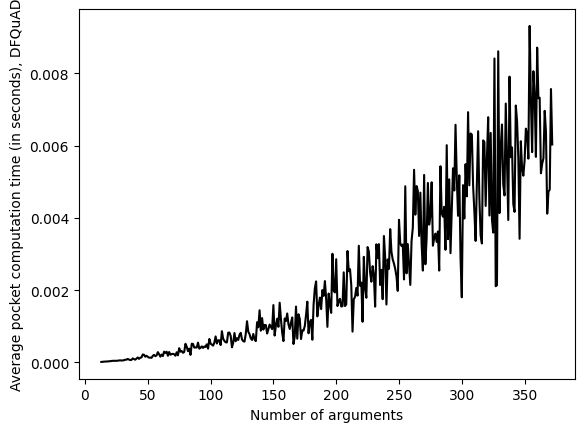

In [25]:
plot = plt.plot(n_arguments_list, avg_pocket_times_dfquad, color='black')
plt.ylabel('Average pocket computation time (in seconds), DFQuAD')
plt.xlabel('Number of arguments')
plt.savefig("avg_df_lin.pdf", format="pdf")

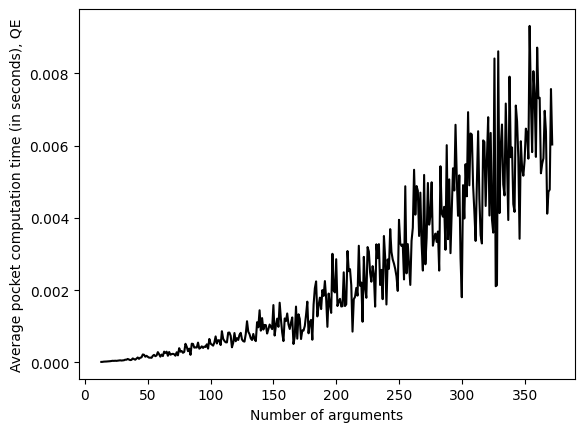

In [26]:
plot = plt.plot(n_arguments_list, avg_pocket_times_qe, color='black')
plt.ylabel('Average pocket computation time (in seconds), QE')
plt.xlabel('Number of arguments')
plt.savefig("avg_qe_lin.pdf", format="pdf")

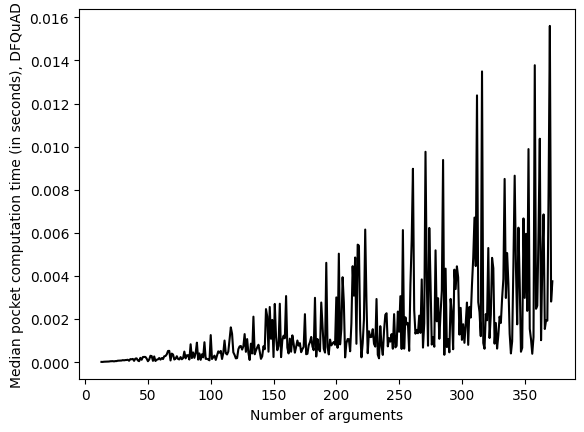

In [27]:
plot = plt.plot(n_arguments_list, med_pocket_times_dfquad, color='black')
plt.ylabel('Median pocket computation time (in seconds), DFQuAD')
plt.xlabel('Number of arguments')
plt.savefig("med_df_lin.pdf", format="pdf")

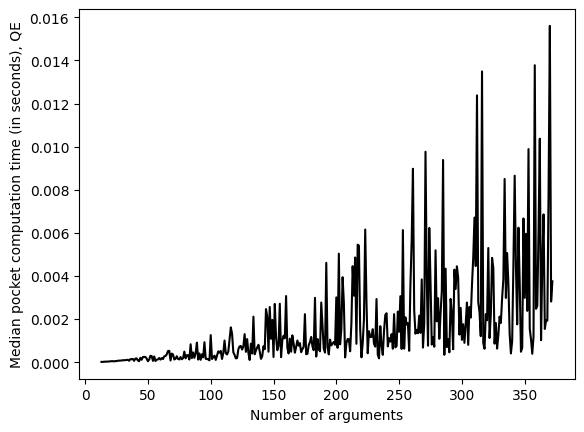

In [28]:
plot = plt.plot(n_arguments_list, med_pocket_times_qe, color='black')
plt.ylabel('Median pocket computation time (in seconds), QE')
plt.xlabel('Number of arguments')
plt.savefig("med_qe_lin.pdf", format="pdf")

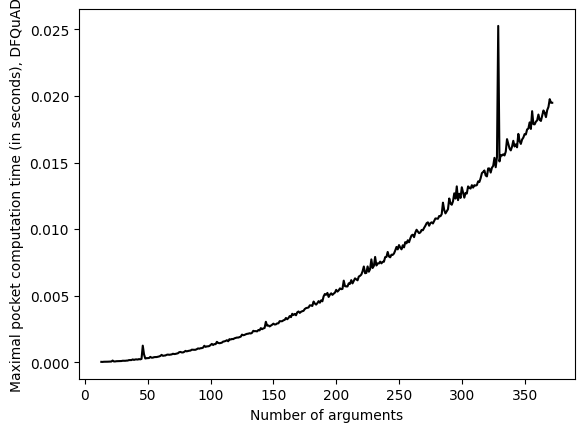

In [29]:
plot = plt.plot(n_arguments_list, max_pocket_times_dfquad, color='black')
plt.ylabel('Maximal pocket computation time (in seconds), DFQuAD')
plt.xlabel('Number of arguments')
plt.savefig("max_df_lin.pdf", format="pdf")

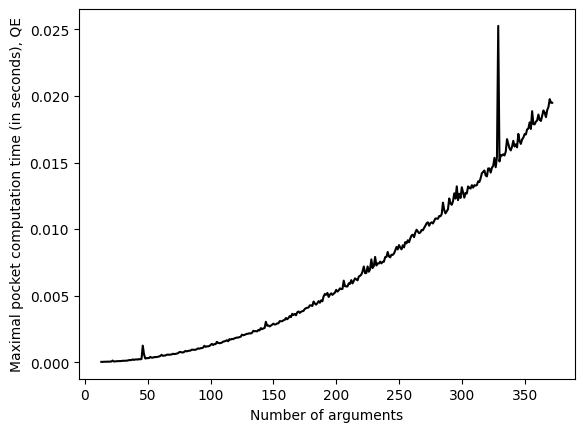

In [30]:
plot = plt.plot(n_arguments_list, max_pocket_times_qe, color='black')
plt.ylabel('Maximal pocket computation time (in seconds), QE')
plt.xlabel('Number of arguments')
plt.savefig("max_qe_lin.pdf", format="pdf")

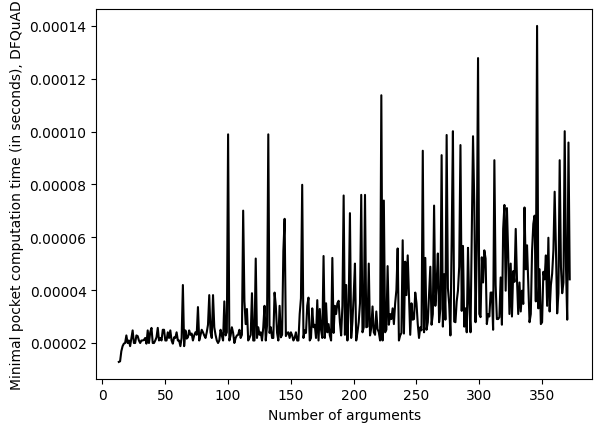

In [31]:
plot = plt.plot(n_arguments_list, min_pocket_times_dfquad, color='black')
plt.ylabel('Minimal pocket computation time (in seconds), DFQuAD')
plt.xlabel('Number of arguments')
plt.savefig("min_df_lin.pdf", format="pdf")

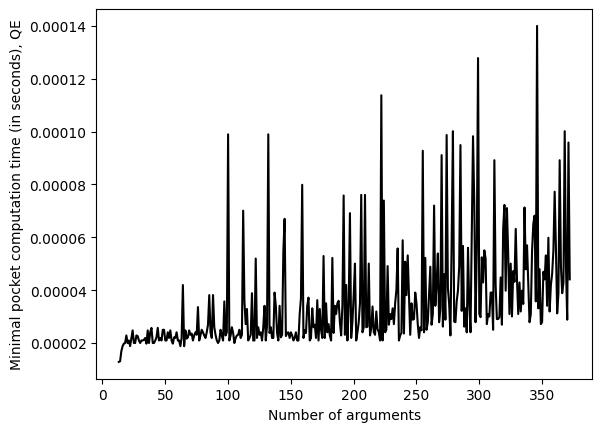

In [32]:
plot = plt.plot(n_arguments_list, min_pocket_times_qe, color='black')
plt.ylabel('Minimal pocket computation time (in seconds), QE')
plt.xlabel('Number of arguments')
plt.savefig("min_qe_lin.pdf", format="pdf")